In [26]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

#Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# # dx = 1 km; Np = 1M; Nt = 5 min
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
# parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
# res='1km'
# Np_str='1e6'

# dx = 1km; Np = 50M
#Importing Model Data
check=False
dir2='/home/air673/koa_scratch/'
data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 100M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_100M.nc') #***
# res='1km'; t_res='1min'; Np_str='100e6'


# dx = 250 m
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

In [27]:
def check_memory():
    import sys
    ipython_vars = ["In", "Out", "exit", "quit", "get_ipython", "ipython_vars"]
    print("Top 10 objects with highest memory usage")
    # Get a sorted list of the objects and their sizes
    mem = {
        key: round(value/1e6,2)
        for key, value in sorted(
            [
                (x, sys.getsizeof(globals().get(x)))
                for x in globals()
                if not x.startswith("_") and x not in sys.modules and x not in ipython_vars
            ],
            key=lambda x: x[1],
            reverse=True)[:10]
    }
    print({key:f"{value} MB" for key,value in mem.items()})
    print(f"\n{round(sum(mem.values()),2)/1000} GB in use overall")

In [28]:
#INITIALIZE DATA FUNCTION
###############################################################
def initiate_array(out_file,vars,t_chunk_size,z_chunk_size,t_size=None,z_size=None):
    # Define array dimensions (adjust based on your data)

    if t_size==None:
        t_size = len(data['time'])  # Number of timesteps
    if z_size==None:
        z_size = len(data['zh'])    # Number of vertical levels
    
    with h5py.File(out_file, 'w') as f: 
        # Check if the dataset 'theta_e' already exists
        for var_name in vars:
            if var_name not in f:
                # Create a dataset with the full size for all time steps (initially empty)
                f.create_dataset(var_name, 
                                 (t_size, z_size),  # Full size for all timesteps
                                 chunks=(t_chunk_size, z_chunk_size))  # Chunks for time axis to allow resizing

In [29]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(PlottingFunctions, inspect.isfunction)]
# functions

In [30]:
#JOB ARRAY SETUP
job_array=True
if job_array==True:

    num_jobs=180 #how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100 #***
    total_elements=len(data['time']) #total num of variables

    if num_jobs >= total_elements:
        raise ValueError("Number of jobs cannot be greater than or equal to total elements.")
    
    job_range = total_elements // num_jobs  # Base size for each chunk
    remaining = total_elements % num_jobs   # Number of chunks with 1 extra 
    
    # Function to compute the start and end for each job_id
    def get_job_range(job_id, num_jobs):
        job_id-=1
        # Add one extra element to the first 'remaining' chunks
        start_job = job_id * job_range + min(job_id, remaining)
        end_job = start_job + job_range + (1 if job_id < remaining else 0)
    
        if job_id == num_jobs - 1: 
            end_job = total_elements #- 1
        return start_job, end_job
    # def job_testing():
    #     #TESTING
    #     start=[];end=[]
    #     for job_id in range(1,num_jobs+1):
    #         start_job, end_job = get_job_range(job_id)
    #         print(start_job,end_job)
    #         start.append(start_job)
    #         end.append(end_job)
    #     print(np.all(start!=end))
    #     print(len(np.unique(start))==len(start))
    #     print(len(np.unique(end))==len(end))
    # job_testing()
    
    job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
    if job_id==0: job_id=1
    start_job, end_job = get_job_range(job_id, num_jobs)
    index_adjust=start_job
    print(f'start_job = {start_job}, end_job = {end_job}')

start_job = 0, end_job = 4


In [31]:
#Indexing Array with JobArray
data=data.isel(time=slice(start_job,end_job))
parcel=parcel.isel(time=slice(start_job,end_job))
#(for 150_000_000 parcels use 500-1000 jobs)

In [32]:
# Reading Back Data Later
##############
def make_data_dict(var_names,read_type):
    if read_type=='h5py':
        with h5py.File(in_file, 'r') as f:
            data_dict = {var_name: f[var_name][start_job:end_job] for var_name in var_names}
            
    elif read_type=='xarray':
        in_data = xr.open_dataset(
            in_file,
            engine='h5netcdf',
            phony_dims='sort',
            chunks={'phony_dim_0': 100, 'phony_dim_1': 1_000_000} 
        )
        data_dict = {k: in_data[k][start_job:end_job].compute().data for k in var_names}
    return data_dict

# read_type='xarray'
read_type='h5py'

In [33]:
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
in_file=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'

var_names = ['A_g', 'A_c', 'Z', 'Y', 'X']
data_dict = make_data_dict(var_names,read_type)
A_g, A_c, Z, Y, X = (data_dict[k] for k in var_names)

# #Making Time Matrix
Nt=len(data['time'])
T = np.broadcast_to(np.arange(Nt)[:, None], A_c.shape)  # shape: (Nt, p)

check_memory(globals())

Top 10 objects with highest memory usage
{'Z': '405.22 MB', 'Y': '405.22 MB', 'X': '405.22 MB', 'A_g': '202.61 MB', 'A_c': '202.61 MB', 'A': '202.61 MB', 'NamespaceMagics': '0.0 MB', 'Normalize': '0.0 MB', 'MaxNLocator': '0.0 MB', 'ScalarFormatter': '0.0 MB'}

1.82349 GB in use overall


In [ ]:
#READING BACK IN
mins_thresh=5
dir3=dir+f'Project_Algorithms/Entrainment/processed_binary_arrays_{res}_{t_res}_{Np_str}.h5'

var_names = ['A_g_Processed', 'A_c_Processed']
data_dict = make_data_dict(var_names,read_type)
A_g_Processed, A_c_Processed = (data_dict[k] for k in var_names)
check_memory(globals())

In [ ]:
###########################################################################################################################################################################

In [35]:
#ENTRAINMENT/DETRAINMENT
########################################################################################################

In [36]:
def ed2d(A, T, Z, type):
    start_time = time.time()
    """
    Function to compute 2D entrainment and update result array based on provided inputs.
    
    Returns a 2D (t,z) array containing the sum of the D array representing entrained parcels, by 1, and detrained parcels, by -1.
    The finally array is then ordered by the appropiate index using the np.add.at function
    
    Parameters:
    - A: The (t,p) lagrangian binary array.
    - T: The (t,p) lagrangian time index array.
    - Z: The (t,p) Lagrangian z index array.

    """
    # Compute the difference between neighboring elements along the first axis
    D = np.zeros_like(A)
    D[1:, :] = A[1:, :] - A[:-1, :]
    
    # Update D for entrainment/detrainment
    if type=='e':
        D[D < 0] = 0
    elif type=='d':
        D[D > 0] = 0
        D2=np.zeros_like(D); D2[:-1]= D[1:]; D=D2.copy() #NEED TO SHIFT TO PREVIOUS TIME TO STORE D CORRECTLY
    
    # Initialize time and vertical dimension arrays
    Nt = len(data['time']); Nz = len(data['zh'])
    
    # Initialize result array
    result = np.zeros((Nt, Nz))
    
    # Use np.add.at to accumulate values in the result array
    np.add.at(result, (T, Z), D)
    
    end_time = time.time()
    print(f"Execution time: {(end_time - start_time)} seconds")
    return result

In [37]:
#TURN PROCESSING ON OR OFF
PROCESSING=False
# PROCESSING=True

# Set A based on PROCESSING state
print('Calculating 2D Entrainment for General Updrafts')
A = A_g if (PROCESSING==False) else A_g_Processed
profile_array_e_g = ed2d(A, T, Z, type='e')
profile_array_d_g = ed2d(A, T, Z, type='d')

# Set A for the second block
print('Calculating 2D Entrainment for Cloudy Updrafts')
A = A_c if (PROCESSING==False) else A_c_Processed
profile_array_e_c = ed2d(A, T, Z, type='e')
profile_array_d_c = ed2d(A, T, Z, type='d')

Calculating 2D Entrainment for General Updrafts
Execution time: 17.35589623451233 seconds
Execution time: 17.59372353553772 seconds
Calculating 2D Entrainment for Cloudy Updrafts
Execution time: 16.770596027374268 seconds
Execution time: 17.02610945701599 seconds


In [38]:
dir2=dir+'Project_Algorithms/Entrainment/job_out_3/'

#SAVING
print('SAVING')
if PROCESSING==False:
    out_file=dir2+f'2D_entrainmentdetrainment_profiles_{res}_{t_res}_{Np_str}_{job_id}.h5'
elif PROCESSING==True:
    out_file=dir2+f'2D_entrainmentdetrainment_profiles_PREPROCESSING_{res}_{t_res}_{Np_str}_{job_id}.h5'

vars=["profile_array_e_g","profile_array_e_c","profile_array_d_g","profile_array_d_c"]
initiate_array(out_file,vars,t_chunk_size=3,z_chunk_size=2)

with h5py.File(out_file, 'a') as f: 
    f['profile_array_e_g'][:]=profile_array_e_g
    f['profile_array_e_c'][:]=profile_array_e_c
    f['profile_array_d_g'][:]=profile_array_d_g
    f['profile_array_d_c'][:]=profile_array_d_c
print('done')

SAVING
done


In [39]:
check_memory(globals())

Top 10 objects with highest memory usage
{'Z': '405.22 MB', 'Y': '405.22 MB', 'X': '405.22 MB', 'A_g': '202.61 MB', 'A_c': '202.61 MB', 'A': '202.61 MB', 'NamespaceMagics': '0.0 MB', 'Normalize': '0.0 MB', 'MaxNLocator': '0.0 MB', 'ScalarFormatter': '0.0 MB'}

1.82349 GB in use overall


In [16]:
#########################################
#RECOMBINE SEPERATE JOB_ARRAYS AFTER
recombine=False #KEEP FALSE IF JOB ARRAY IS RUNNING
# recombine=True

In [18]:
if recombine==True:
    PROCESSING=False
    # PROCESSING=True
    
    dir2=dir+'Project_Algorithms/Entrainment/job_out_3/'
    dir3=dir+'Project_Algorithms/Entrainment/'
    
    if PROCESSING==False:
        out_file=dir3+f'2D_entrainmentdetrainment_profiles_{res}_{t_res}_{Np_str}.h5'
    elif PROCESSING==True:
        out_file=dir3+f'2D_entrainmentdetrainment_profiles_PREPROCESSING_{res}_{t_res}_{Np_str}.h5'
    
    
    
    vars=["profile_array_e_g","profile_array_e_c","profile_array_d_g","profile_array_d_c"]
    initiate_array(out_file,vars,t_chunk_size=50,z_chunk_size=2)
    
    with h5py.File(out_file, 'r+') as f_out:
        num_jobs=60
        for job_id in np.arange(1,num_jobs+1):
            if np.mod(job_id,5)==0: print(f"job_id = {job_id}")
            [a,b] = get_job_range(job_id,num_jobs)
    
            if PROCESSING==False:
                in_file=dir2+f'2D_entrainmentdetrainment_profiles_{res}_{t_res}_{Np_str}_{job_id}.h5'
            elif PROCESSING==True:
                in_file=dir2+f'2D_entrainmentdetrainment_profiles_PREPROCESSING_{res}_{t_res}_{Np_str}_{job_id}.h5'
            with h5py.File(in_file, 'r') as f_in: 
                for var in vars:
                    f_out[var][a:b]=f_in[var][:]

In [19]:
############################################################
#PLOTTING
plotting=False #KEEP FALSE IF JOB ARRAY IS RUNNING
# plotting=True

In [20]:
if plotting==True:
    #constants
    Cp=1004 #Jkg-1K-1
    Cv=717 #Jkg-1K-1
    Rd=Cp-Cv #Jkg-1K-1
    eps=0.608
    
    Lx=(data['xf'][-1].item()-data['xf'][0].item())*1000 #x length (m)
    Ly=(data['yf'][-1].item()-data['yf'][0].item())*1000 #y length (m)
    Np=len(parcel['xh']) #number of lagrangian parcles
    dt=(data['time'][1]-data['time'][0]).item()/1e9 #sec
    dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
    dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
    xs=data['xf'].values*1000
    ys=data['yf'].values*1000
    zs=data['zf'].values*1000
    
    def zf(z):
        k=z #z is the # level of z
        out=data['zf'].values[k]*1000
        
        return out
    # def rho(x,y,z,t):
    #     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
    #     p0=101325 #Pa
    #     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
    #     T=theta*(p/p0)**(Rd/Cp)
    #     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
    #     # Tv=T*(1+eps*qv)
    #     Tv=T*(eps+qv)/(eps*(1+qv))
    #     rho = p/(Rd*Tv)
    #     out=rho
    #     return out
    
    def rho(x,y,z,rho_data_t):
        out=rho_data_t[z,y,x]
        return out
    def m(t):
        rho_data_t=data['rho'].isel(time=t).data
        
        m=0
        #triple sum
        for k in range(len(data['zh'])):
            dz=(zf(k+1)-zf(k))
            for j in range(len(data['yh'])):
                for i in range(len(data['xh'])):
                    rho_out=rho(i,j,k,rho_data_t)
                    m+=rho_out*dz
                    
        #triple sum
        out=m*dx*dy/Np
        return out


In [21]:
if plotting==True:
    #Calculate Mass Constant
    # calculate='single_time'
    calculate=False
    
    if calculate==True:
        Nt=len(data['time'])
        m_arr=np.zeros((Nt))
        for t in np.arange(Nt):
            if np.mod(t,25)==0: print(t)
            # m_arr[t]=m(t) #UNCOMMENT FOR FULL CALCULATION
        # np.save('Mass_Array.npy', m_arr)
        np.save('Mass_Array_1min.npy', m_arr)
    elif calculate=='single_time':
        Nt=len(data['time'])
        m_arr=np.zeros((Nt))
    
        t=len(data['time'])//2
        m_300=m(t)
        for t in np.arange(Nt):
            m_arr[t]=m_300 #UNCOMMENT FOR FULL CALCULATION
        # np.save('Mass_Array.npy', m_arr)
        np.save('Mass_Array_1min.npy', m_arr)
    else:
        dir3=dir+f'Project_Algorithms/Entrainment/'
        # m_arr = np.load('Mass_Array.npy')
        m_arr = np.load('Mass_Array_1min.npy')
    
    # # TESTING
    # lst=[]
    # for t in np.arange(133):
    #     lst.append(m_arr[t])
    
    # plt.plot(lst)
    # (np.max(lst)-np.min(lst))*100/np.mean(lst)

In [22]:
if plotting==True:
    PROCESSING=False
    # PROCESSING=True
    
    if PROCESSING==False:
        dir3=dir+f'Project_Algorithms/Entrainment/2D_entrainmentdetrainment_profiles_{res}_{t_res}_{Np_str}.h5'
    if PROCESSING==True:
        dir3=dir+f'Project_Algorithms/Entrainment/2D_entrainmentdetrainment_profiles_PREPROCESSING_{res}_{t_res}_{Np_str}.h5'
    with h5py.File(dir3, "r") as h5f:
        profile_array_e_g = h5f["profile_array_e_g"][:]
        profile_array_e_c = h5f["profile_array_e_c"][:]
        profile_array_d_g = h5f["profile_array_d_g"][:]
        profile_array_d_c = h5f["profile_array_d_c"][:]

In [23]:
if plotting==True:
    type='general'
    # type='cloudy'
    
    def apply_constant(profile_array,apply):
        if apply==True:
            Nt=profile_array.shape[0]
            Nz=profile_array.shape[1]
        
            profile_array/=(Lx*Ly*dt)
            for t in np.arange(Nt):
                profile_array[t]*=m_arr[t]
            for z in np.arange(Nz):
                dz=zf(z+1)-zf(z)
                profile_array[:,z]/=dz
        return profile_array
    #APPLY CONSTANTS TO ENTRAINMENT VALUE
    ##################################################
    profile_array_e_g=apply_constant(profile_array_e_g,apply=True)
    profile_array_e_c=apply_constant(profile_array_e_c,apply=True)
    profile_array_d_g=-apply_constant(profile_array_d_g,apply=True)
    profile_array_d_c=-apply_constant(profile_array_d_c,apply=True)
    ##################################################
    
    if type=='general':
        profile_array_e=profile_array_e_g
        profile_array_d=profile_array_d_g
        profile_array_net=profile_array_e-profile_array_d
    if type=='cloudy':
        profile_array_e=profile_array_e_c
        profile_array_d=profile_array_d_c
        profile_array_net=profile_array_e-profile_array_d

In [24]:
if plotting==True:
    #Plotting
    ############################################################
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    import numpy as np
    
    fig = plt.figure(figsize=(10, 8))
    gs = GridSpec(2, 2, figure=fig)
    
    ######
    cmap1 = plt.cm.viridis
    cmap2 = plt.cm.seismic 
    n_levels=29
    ######
    
    ######
    vmax_shared = np.max([np.max(profile_array_e), np.max(profile_array_d)])
    norm_shared = mcolors.Normalize(vmin=0, vmax=vmax_shared)
    ######
    
    # First subplot: Entrainment
    ########################################
    ax1 = fig.add_subplot(gs[0, 0])
    # contour1 = ax1.contourf(profile_array_e.T, cmap=cmap1)
    contour1 = ax1.contourf(profile_array_e.T, cmap=cmap1, norm=norm_shared, levels=n_levels)
    cbar1=fig.colorbar(contour1, ax=ax1)
    Nz = len(data['zh'])
    ax1.set_yticks(np.arange(Nz))
    new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
    ax1.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
    ax1.set_ylabel('z (km)');ax1.set_xlabel('t (timesteps)')
    ax1.set_title('Entrainment using Lagrangian Binary Array',fontsize=8)
    
    # Second subplot: Detrainment
    ########################################
    ax2 = fig.add_subplot(gs[0, 1])
    # contour2 = ax2.contourf(profile_array_d.T, cmap=cmap1)
    contour2 = ax2.contourf(profile_array_d.T, cmap=cmap1, norm=norm_shared, levels=n_levels)
    cbar2 = fig.colorbar(contour2, ax=ax2)
    ax2.set_yticks(np.arange(Nz))
    new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
    ax2.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
    ax2.set_ylabel('z (km)');ax2.set_xlabel('t (timesteps)')
    ax2.set_title('Detrainment')
    
    # Third subplot: Net Entrainment
    ########################################
    
    
    # #OLD METHOD, DOESNT BALANCE COLOR LEVELS
    # # Normalize with a balanced vmin and vmax
    # levels=49; vmin=np.min(profile_array_net);vmax=np.max(profile_array_net)
    # # vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
    # norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
    
    # Normalize with a balanced vmin and vmax
    vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
    levels = np.linspace(vmin, vmax, n_levels)
    norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)
    cmap = plt.get_cmap('RdBu_r', n_levels)
    
    ax3 = fig.add_subplot(gs[1, 0])
    contour3 = ax3.contourf((profile_array_net).T, cmap=cmap2, norm=norm, levels=levels)
    # contour3 = ax3.contourf((profile_array_net).T, cmap=cmap2, levels=30,vmin=-np.max(abs(profile_array_net)), vmax=+np.max(abs(profile_array_net)))
    # cmap2 = plt.get_cmap('RdBu', 29);contour3 = ax3.pcolor(profile_array_net.T, cmap=cmap2, norm=norm, shading='auto')
    cbar3 = fig.colorbar(contour3, ax=ax3, norm=norm)
    
    #FIXING TICKS
    ax3.set_yticks(np.arange(Nz))
    new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
    ax3.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
    ax3.set_ylabel('z (km)');ax3.set_xlabel('t (timesteps)')
    ax3.set_title('Entrainment - Detrainment')
    
    #FIXING SCIENTIFIC NOTATION
    
    def apply_scientific_notation_colorbar(cbars):
        from matplotlib.ticker import ScalarFormatter
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((-2, 2))  # Adjust the range for scientific notation
        for cbar in cbars:  # These must be Colorbar instances
            cbar.formatter = formatter
            cbar.update_ticks()
    apply_scientific_notation_colorbar([cbar1,cbar2,cbar3])
    
    # Display the plot
    plt.tight_layout()
    
    #TESTING
    print(f"Max of profile_array_e: {np.max(profile_array_e)}")
    print(f"Max of profile_array_d: {np.max(profile_array_d)}")

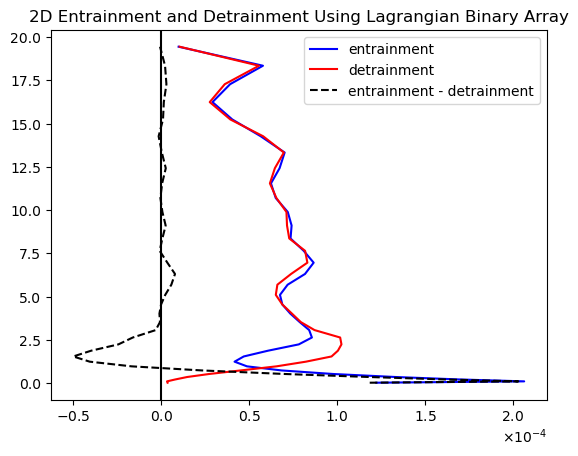

In [24]:
if plotting==True:
    e=np.mean(profile_array_e,axis=(0))
    d=np.mean(profile_array_d,axis=(0))
    net=np.mean(profile_array_e-profile_array_d,axis=(0))
    
    plt.plot(e,data['zh'],color='blue',label='entrainment')
    plt.plot(d,data['zh'],color='red',label='detrainment')
    plt.plot(net,data['zh'],linestyle='dashed',color='black',label='entrainment - detrainment')
    plt.axvline(0,color='black')
    
    plt.legend(); plt.title('2D Entrainment and Detrainment Using Lagrangian Binary Array')
    
    from matplotlib.ticker import ScalarFormatter
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-1, 1))
    plt.gca().xaxis.set_major_formatter(formatter)

In [ ]:
##################################################################
#TESTING

In [ ]:
# # Assuming profile_array_e_g is already defined
# Nt = profile_array_e.shape[0]  # Total number of time steps
# Nz = profile_array_e.shape[1]
# zhs = data['zh']

# # Calculate the number of rows and columns needed for the subplots
# cols = 4  # You can adjust this to change the number of columns
# rows = int(np.ceil(Nt / 10 / cols))  # Calculate rows dynamically based on Nt (max 16 plots)

# # Create a figure with a grid of subplots, adjust the figure size for better spacing
# fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
# axes = axes.flatten()  # Flatten axes to make indexing easier

# # Loop through time steps, creating a plot for each
# for i, t in enumerate(np.arange(0, Nt, 10)):  # Use np.arange with step size 10
#     plot_data = profile_array_net[t]
    
#     # Select the corresponding axis
#     ax = axes[i]
    
#     # Plot the data for the current time step
#     ax.plot(plot_data, zhs, color='black')  # Adjust to match your data's structure
#     ax.axvline(0,linestyle='dashed',color='k')
    
#     # Set title for the subplot
#     ax.set_title(f"Time Step {t}")

#     apply_scientific_notation([ax])

# # Remove any unused axes (if there are fewer plots than grid spaces)
# for j in range(i + 1, len(axes)):
#     axes[j].axis('off')

# # Add global labels and title
# plt.xlabel('X-axis label')  # Replace with actual x-axis label
# plt.ylabel('Z (km)')  # Replace with your y-axis label

# # Adjust layout for better spacing
# plt.tight_layout()
# plt.show()


In [ ]:
# # Assuming profile_array_e_g is already defined
# Nt = profile_array_e.shape[0]  # Total number of time steps
# Nz = profile_array_e.shape[1]
# zhs = data['zh']

# # Calculate the number of rows and columns needed for the subplots
# cols = 4  # You can adjust this to change the number of columns
# rows = int(np.ceil(Nt / 10 / cols))  # Calculate rows dynamically based on Nt (max 16 plots)

# # Create a figure with a grid of subplots, adjust the figure size for better spacing
# fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
# axes = axes.flatten()  # Flatten axes to make indexing easier

# # Loop through time steps, creating a plot for each
# for i, t in enumerate(np.arange(55,67, 1)):  # Use np.arange with step size 10
#     plot_data = profile_array_net[t]
    
#     # Select the corresponding axis
#     ax = axes[i]
    
#     # Plot the data for the current time step
#     ax.plot(plot_data, zhs, color='black')  # Adjust to match your data's structure
#     ax.axvline(0,linestyle='dashed',color='k')
    
#     # Set title for the subplot
#     ax.set_title(f"Time Step {t}")

#     apply_scientific_notation([ax])

# # Remove any unused axes (if there are fewer plots than grid spaces)
# for j in range(i + 1, len(axes)):
#     axes[j].axis('off')

# # Add global labels and title
# plt.xlabel('X-axis label')  # Replace with actual x-axis label
# plt.ylabel('Z (km)')  # Replace with your y-axis label

# # Adjust layout for better spacing
# plt.tight_layout()
# plt.show()


In [ ]:
# # w_tz=data['winterp'].mean(dim=('xh','yh'))
# # qc_tz=data['qc'].mean(dim=('xh','yh'))
# # # w_tz=data['winterp'].isel(yh=100).mean(dim=('xh'))
# # # qc_tz=data['qc'].isel(yh=100).mean(dim=('xh'))

# # def DdzStretch(f):
# #     import numpy as np
# #     #f must be interpolated to cell centers
# #     dz=np.diff(data['zf'].values)
# #     dz=dz.copy()[np.newaxis, :, np.newaxis, np.newaxis]
    
# #     ddz=np.zeros_like(f)
# #     ddz[:, 1:-1] = (f[:, 2:] - f[:, :-2]) / (2 * dz[:, 1:-1])
# #     ddz[:, 0] = (f[:, 1] - f[:, 0]) / dz[:, 0]  # Forward difference 
# #     ddz[:, -1] = (f[:, -1] - f[:, -2]) / dz[:, -1]  # Backward difference 
# #     return ddz

# # u=data['uinterp'].data
# # dudz=DdzStretch(u)
# # dudz_tz=np.mean(dudz,axis=(2,3))
# # # dudz_tz=np.mean(dudz[:,:,100],axis=(2))

# # w=data['winterp'].data
# # dwdz=DdzStretch(w)
# # dwdz_tz=np.mean(dwdz,axis=(2,3))
# # # dwdz_tz=np.mean(dwdz[:,:,100],axis=(2))

# fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# # Plot the first contour plot for w_tz
# ax1 = axs[0, 0]  # First subplot (top-left)
# c1 = ax1.contourf(w_tz.T,levels=20)  # Transpose if necessary
# fig.colorbar(c1, ax=ax1)
# ax1.set_title('w')

# # Plot the second contour plot for du/dz
# ax2 = axs[0, 1]  # Second subplot (top-right)
# c2 = ax2.contourf(dudz_tz.T,levels=20)  # Transpose if necessary
# fig.colorbar(c2, ax=ax2)
# ax2.set_title('du/dz')

# # Plot the third contour plot for dw/dz
# ax3 = axs[1, 0]  # Third subplot (bottom-left)
# c3 = ax3.contourf(dwdz_tz.T,cmap='RdBu',levels=20,vmax=0.004)  # Transpose if necessary
# fig.colorbar(c3, ax=ax3)
# ax3.set_title('dw/dz')

# # Plot the third contour plot for dw/dz
# ax4 = axs[1, 1]  # Third subplot (bottom-left)
# c4 = ax4.contourf(qc_tz.T,cmap='RdBu',levels=20)  # Transpose if necessary
# fig.colorbar(c4, ax=ax4)
# ax4.set_title('qc')